# Inference Pipelines

In this notebook, we redo some of the examples shown before using the builtin `Pipeline` functionality of `DFLike`.

Pipelines can use used to automatically construct parameter -> log-posterior functions without having to deal with manual vectorization or indexing.

In [ ]:
import jax
from jax import numpy as jnp
from jax import scipy as jsc
from jax import random as jrd

import numpy as np
import matplotlib.pyplot as plt

import camb

import sys
sys.path.insert(0, "../")

import mflike_jax
import mflike_jax.util

import pprint

try:
    from tqdm.notebook import tqdm
except:
    tqdm = lambda x: x

import sys

sys.path.insert(0, "cosmopower")

import cosmopower as cp
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX

In [2]:
# We can use the same likelihoods and theories we had before:
like = mflike_jax.MFLike_jax("../act_dr6.yaml")
fg_model = mflike_jax.BandpowerForegrounds("../act_dr6_foregrounds.yaml", like)

parser = cp.YAMLParser("jense_2024_emulators/jense_2023_cmb_camb_lcdm.yaml", root_dir="jense_2024_emulators")
cmb = mflike_jax.Cosmopower(parser)

prior = mflike_jax.Prior({
    "calG_all": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.003),

    "cal_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.013),
    "cal_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0016),
    "cal_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0020),
    "cal_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0018),
    "cal_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0024),

    "bandint_shift_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=3.6),
    "bandint_shift_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.0),
    "bandint_shift_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.3),
    "bandint_shift_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.2),
    "bandint_shift_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.1),

    "a_gtt": lambda x: jsc.stats.norm.logpdf(x, loc=7.95, scale=0.32),
    "a_gte": lambda x: jsc.stats.norm.logpdf(x, loc=0.432, scale=0.03),
    "a_gee": lambda x: jsc.stats.norm.logpdf(x, loc=0.1681, scale=0.017),

    "tau": lambda x: jsc.stats.norm.logpdf(x, loc=5.44e-2, scale=7e-3),
})

# But now we list them all in a single `Pipeline` instance:
pipeline = mflike_jax.Pipeline([like, fg_model, cmb], prior=prior)

Assuming data rows are in the correct order as it was before version 1.0.
Failed to restore network derived: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_derived:  does not exist..


E0000 00:00:1790590660.149904   31045 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Failed to restore network Hubble: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Hubble:  does not exist..
Failed to restore network angular_diameter_distance: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_angular_diameter_distance:  does not exist..


In [3]:
# The Pipeline works similar to the functions we have seen before, for example we can check which parameters are used in the pipeline.
pprint.pprint(pipeline.parameters)

['calG_all',
 'cal_dr6_pa4_f220',
 'calE_dr6_pa4_f220',
 'cal_dr6_pa5_f090',
 'calE_dr6_pa5_f090',
 'cal_dr6_pa5_f150',
 'calE_dr6_pa5_f150',
 'cal_dr6_pa6_f090',
 'calE_dr6_pa6_f090',
 'cal_dr6_pa6_f150',
 'calE_dr6_pa6_f150',
 'bandint_shift_dr6_pa4_f220',
 'bandint_shift_dr6_pa5_f090',
 'bandint_shift_dr6_pa5_f150',
 'bandint_shift_dr6_pa6_f090',
 'bandint_shift_dr6_pa6_f150',
 'a_kSZ',
 'a_tSZ',
 'alpha_tSZ',
 'a_c',
 'alpha_c',
 'xi',
 'beta_cib',
 'T_d',
 'a_p',
 'alpha_p',
 'a_s',
 'alpha_s',
 'beta_s',
 'a_gtt',
 'alpha_dT',
 'beta_d',
 'T_effd',
 'a_pste',
 'a_gte',
 'alpha_dE',
 'a_psee',
 'a_gee',
 'h',
 'omch2',
 'tau',
 'logA',
 'ombh2',
 'ns']


In [4]:
# Some of these parameters are not ones we are interested in, we can restrict our entire pipeline to only use the ones we do want to vary:
fixed_parameters = {
    "alpha_c": 0.8,
    "alpha_p": 1.0,
    "alpha_s": 1.0,
    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,

    "calE_dr6_pa4_f220": 1.0,
}

pipeline.restrict(fixed_parameters)

# Notice that the aforementioned parameters will be gone.
pprint.pprint(pipeline.parameters)

['calG_all',
 'cal_dr6_pa4_f220',
 'cal_dr6_pa5_f090',
 'calE_dr6_pa5_f090',
 'cal_dr6_pa5_f150',
 'calE_dr6_pa5_f150',
 'cal_dr6_pa6_f090',
 'calE_dr6_pa6_f090',
 'cal_dr6_pa6_f150',
 'calE_dr6_pa6_f150',
 'bandint_shift_dr6_pa4_f220',
 'bandint_shift_dr6_pa5_f090',
 'bandint_shift_dr6_pa5_f150',
 'bandint_shift_dr6_pa6_f090',
 'bandint_shift_dr6_pa6_f150',
 'a_kSZ',
 'a_tSZ',
 'alpha_tSZ',
 'a_c',
 'xi',
 'beta_cib',
 'a_p',
 'a_s',
 'beta_s',
 'a_gtt',
 'a_pste',
 'a_gte',
 'a_psee',
 'a_gee',
 'h',
 'omch2',
 'tau',
 'logA',
 'ombh2',
 'ns']


In [5]:
# Now we can compute the log-posterior at the fiducial.
parameter_values = {
    "ombh2": 0.022,
    "omch2": 0.117,
    "h": 0.67,
    "ns": 0.97,
    "logA": 3.055,
    "tau": 0.06,

    "a_tSZ": 3.4,
    "alpha_tSZ": -0.5,
    "a_kSZ": 1.5,
    "a_c": 3.7,
    "a_p": 7.7,
    "beta_cib": 1.9,
    "xi": 0.09,
    "a_s": 2.9,
    "beta_s": -2.8,
    "a_pste": -0.026,
    "a_psee": 0.02,

    "a_gtt": 7.95,
    "a_gte": 0.423,
    "a_gee": 0.1681,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 1.0,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa5_f090": 1.0,
    "calE_dr6_pa5_f150": 1.0,
    "calE_dr6_pa6_f090": 1.0,
    "calE_dr6_pa6_f150": 1.0,

    "bandint_shift_dr6_pa4_f220": 0.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": 0.0,
    "bandint_shift_dr6_pa6_f090": 0.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

theta = jnp.array([parameter_values[p] for p in pipeline.parameters])

print(pipeline.logprior(theta))
print(pipeline.loglike(theta))
print(pipeline.logposterior(theta))

32.868935
-2187.0298
-2154.161


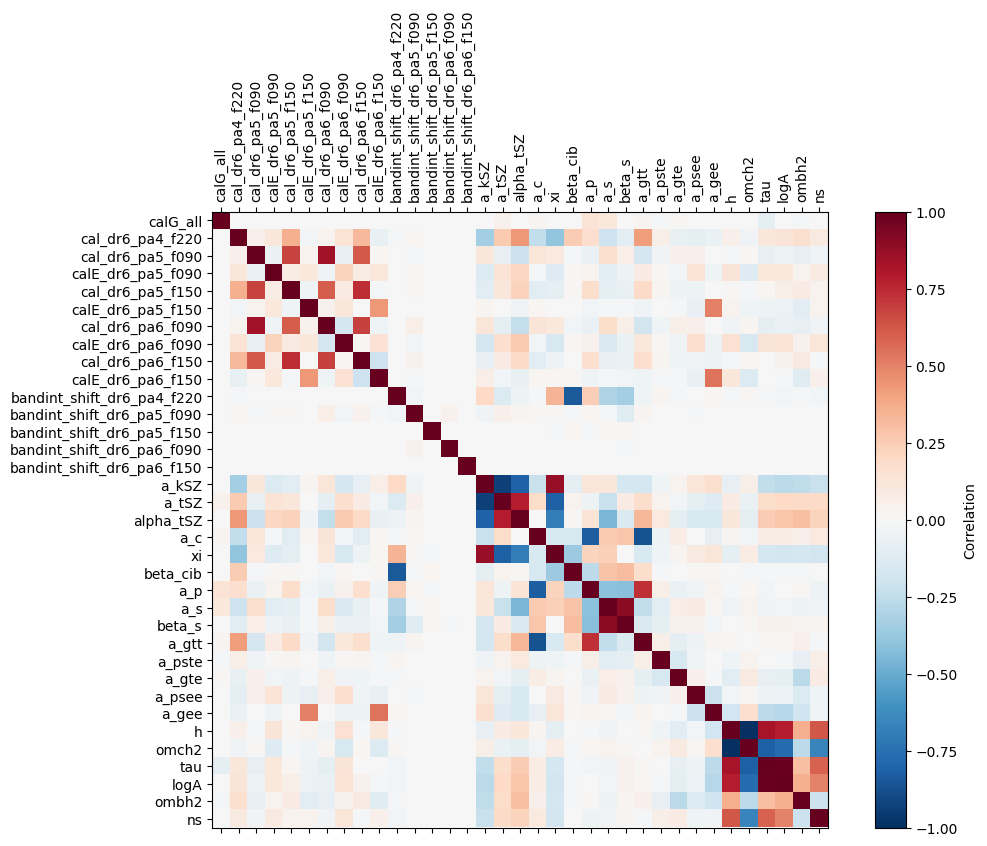

In [6]:
# We can compute the fisher matrix directly through the pipeline:
F = pipeline.fisher(theta)
cov = jnp.linalg.inv(F)
corr = cov / np.sqrt(np.diag(cov)[:,None] * np.diag(cov)[None,:])

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

im = ax.matshow(corr, vmin=-1., vmax=1., cmap="RdBu_r")

ax.set_xticks(range(len(pipeline.parameters)))
ax.set_xticklabels(pipeline.parameters, rotation=90)
ax.set_yticks(range(len(pipeline.parameters)))
ax.set_yticklabels(pipeline.parameters)

fig.colorbar(im, ax=ax, label="Correlation");

In [ ]:
# We can minimize a chain quickly:
chain = pipeline.minimize(theta, max_steps=100, learning_rate=1e-2)

In [95]:
import matplotlib.patches as mpt
import matplotlib.transforms as mtr

def add_ellipse(ax, m, s, cov, nstd=1., **kwargs):
    R = cov / (s[0] * s[1])
    erx = np.sqrt(1. + R)
    ery = np.sqrt(1. - R)

    ell = mpt.Ellipse((0, 0), width=2*erx, height=2*ery, **kwargs)
    mx, my = m
    sx, sy = s

    tf = mtr.Affine2D().rotate_deg(45).scale(nstd*sx, nstd*sy).translate(mx, my)
    ell.set_transform(tf + ax.transData)
    ax.add_patch(ell)

F_bf = pipeline.fisher(chain[-1])
cov_bf = jnp.linalg.inv(F_bf)

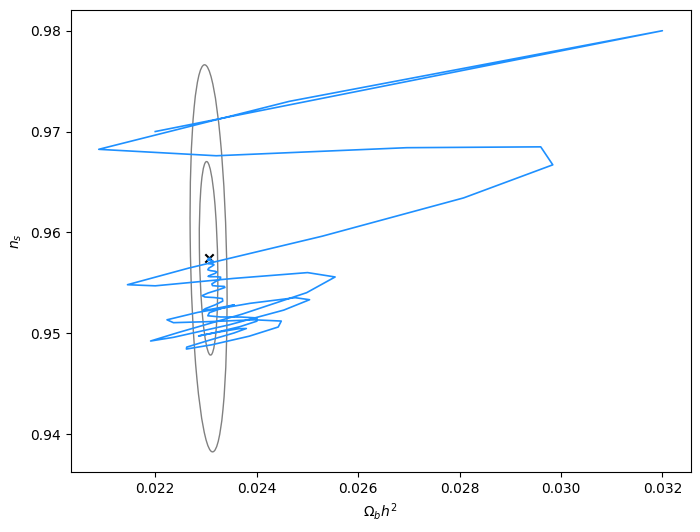

In [104]:
trace = np.array(chain)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

i = pipeline.parameters.index("ombh2")
j = pipeline.parameters.index("ns")

ax.plot(trace[:,i], trace[:,j], c="dodgerblue", lw=1.2)
ax.scatter(trace[-1,i], trace[-1,j], c="k", marker="x")

add_ellipse(ax, (trace[-1,i], trace[-1,j]), (np.sqrt(np.diag(cov)[i]), np.sqrt(np.diag(cov)[j])), cov[i,j], nstd=1., fc="None", edgecolor="grey")
add_ellipse(ax, (trace[-1,i], trace[-1,j]), (np.sqrt(np.diag(cov)[i]), np.sqrt(np.diag(cov)[j])), cov[i,j], nstd=2., fc="None", edgecolor="grey")

ax.set_xlabel(r"$\Omega_b h^2$")
ax.set_ylabel(r"$n_s$");